# Self-Supervision Video Similarity Learning

This is a step-by-step demonstration of different types of augmentations used during training of the similarity network, as well as the input and output similarity matrices of a trained model.

## 0. Environment preperation
Clone the repository

In [1]:
# !git clone https://github.com/gkordo/s2vs
%cd s2vs
# !pip install -r requirements.txt

[Errno 2] No such file or directory: 's2vs'
/Users/dmytroshendryk/Documents/Projects/aero/video_deduplication/s2vs/notebooks


/Users/dmytroshendryk/Documents/Projects/aero/video_deduplication/s2vs/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [2]:
import sys

In [3]:
PROJECT_ROOT = "/Users/dmytroshendryk/Documents/Projects/aero/video_deduplication/s2vs"
sys.path.append(PROJECT_ROOT)

Import all necessary classes and functions

In [4]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils import animate, load_video_opencv
from datasets.augmentations import WeakAugmentations, StrongAugmentations
%matplotlib inline

## 1. Augmentations

### 1.1 Video loading

We load a video given the path to its video file. The video is loaded with one fps and resized so that the small side has 256 pixels. For demonstration purposes, we select the first 10 frames of the video.

Video tensor shape: (10, 256, 455, 3)


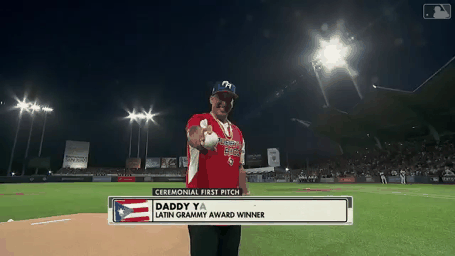

In [4]:
video_path = f'{PROJECT_ROOT}/data/examples/video1.mp4' # video file
video1 = load_video_opencv(video_path, fps=1, resize=256) # video loading
video1 = video1[:10] # select 10 frames
print('Video tensor shape:', video1.shape)
animate(video1, save_file=f'{PROJECT_ROOT}/data/examples/video1/orignal_video.gif')

### 1.2 Weak Augmentations
We first apply weak augmentations to the original video. These include conventional geometric transformations, i.e. random resized crop with scale and aspect-ratio jittering, and random horizontal flip.

In [5]:
# Instantiate an object for weak augmentations
weak_aug = WeakAugmentations(window_sz=10)
weak_aug

WeakAugmentations(frame_sz=224, window_sz=10)

Video tensor shape: (10, 224, 224, 3)


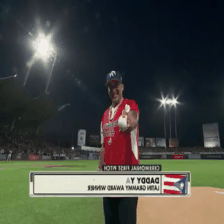

In [6]:
# Apply weak augmentations to the original video
weak_ver1 = weak_aug(video1.copy()).numpy()
print('Video tensor shape:', weak_ver1.shape)
animate(weak_ver1, save_file=f'{PROJECT_ROOT}/data/examples/video1/waek_video.gif')

### 1.3 Strong Augmentations
Then, we apply strong augmentations to the same original video. Four types of transformations are included: Global Transformations (GT), Frame Transformations (GA), Temporal Transformationstions (TT) and Video-in-Video (ViV).

In [7]:
# Instantiate an object for strong augmentations
strong_aug = StrongAugmentations(window_sz=10, augmentations='GT,FT,TT,ViV')
strong_aug

StrongAugmentations(frame_sz=224, window_sz=10
	global=RandAugment(num_ops=2, magnitude=9, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None),
	frame=FrameTransforms(p_overlay=0.3, p_blur=0.5),
	temporal=TemporalTransformations(p_tsd=0.5, p_ff=0.1, p_sm=0.1, p_rev=0.1, p_pau=0.1),
	viv=VideoInVideo(p=0.3, mix_lamda=(0.3, 0.7))
)

Video tensor shape: torch.Size([10, 224, 224, 3])


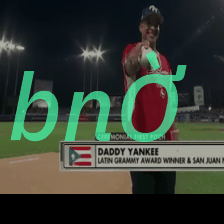

In [8]:
# Apply strong augmentations to the original video
strong_ver1 = strong_aug(video1.copy())
print('Video tensor shape:', strong_ver1.shape)
animate(strong_ver1, save_file=f'{PROJECT_ROOT}/data/examples/video1/strong_video.gif')

We need another video to test the Video-in-Video transformation. We follow the same process to load the new video.

Video tensor shape: (10, 256, 455, 3)


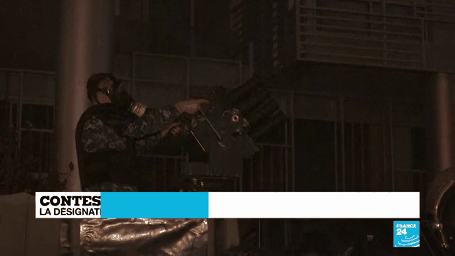

In [9]:
video_path = f'{PROJECT_ROOT}/data/examples/video2.mp4' # video file
video2 = load_video_opencv(video_path, fps=1, resize=256)[:10] # video loading and frome selection
print('Video tensor shape:', video2.shape)
animate(video2, save_file=f'{PROJECT_ROOT}/data/examples/video2/original_video.gif')

Video tensor shape: torch.Size([10, 224, 224, 3])


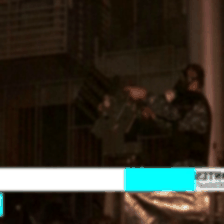

In [10]:
# Apply strong augmentations to the second original video
strong_ver2 = strong_aug(video2.copy())
print('Video tensor shape:', strong_ver2.shape)
animate(strong_ver2, save_file=f'{PROJECT_ROOT}/data/examples/video2/strong_video.gif')

Then apply Video-in-Video transformation on both strongly augmented videos.

Video1 tensor shape: torch.Size([10, 224, 224, 3])


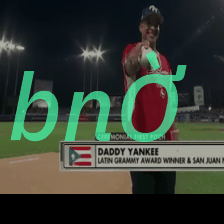

Video2 tensor shape: torch.Size([10, 224, 224, 3])


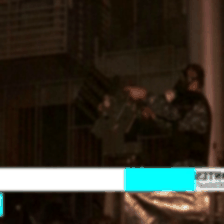

Labels: [[1. 0.]
 [0. 1.]]


In [11]:
# Create a batch based on the two videos
batch = torch.cat([strong_ver1.clone()[None, ...], strong_ver2.clone()[None,...]])
labels = np.array([[1., 0.], [0., 1.]])

# Apply video-in-video transformation
viv_ver, labels = strong_aug.mixup(batch, labels)
print('Video1 tensor shape:', viv_ver[0].shape)
animate(viv_ver[0], save_file=f'{PROJECT_ROOT}data/examples/video1/viv_video.gif')
print('Video2 tensor shape:', viv_ver[1].shape)
animate(viv_ver[1], save_file=f'{PROJECT_ROOT}data/examples/video2/viv_video.gif')
print('Labels:', labels)

## 2. Similarity matrices

### 2.1 Model

First, we need to initialize all necessary models and load the pre-trained weights. We load the feature extraction model and the video similarity network.

In [6]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)
feat_ext = torch.hub.load('gkordo/s2vs:main', 'resnet50_LiMAC').to(device).eval() # load feature extractor
sim_net = torch.hub.load('gkordo/s2vs:main', 's2vs_dns').to(device).eval() # load pretrained similarity network

mps


Using cache found in /Users/dmytroshendryk/.cache/torch/hub/gkordo_s2vs_main
Using cache found in /Users/dmytroshendryk/.cache/torch/hub/gkordo_s2vs_main
Downloading: "https://mever.iti.gr/s2vs/weights/s2vs_dns.pth" to /Users/dmytroshendryk/.cache/torch/hub/checkpoints/s2vs_dns.pth
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.36M/1.36M [00:00<00:00, 2.06MB/s]


We create a function to plot and store our similarity matrices.

In [14]:
@torch.no_grad()
def plot_sim_mat(query, target, apply_visil=False, save_file=None):
    query = feat_ext(query.to(device))
    target = feat_ext(target.to(device))
    if apply_visil:
        query = sim_net.index_video(query)
        target = sim_net.index_video(target)
    sim_mat, sim_mask = sim_net.similarity_matrix(query, target, apply_visil=apply_visil, normalize=True)

    sim = sim_net.v2v_sim(sim_mat, sim_mask)
    print(f"Similarity score {sim.cpu().numpy()[0][0] * 100:.2f} %")
    
    sim_mat = sim_mat[0, 0].cpu().numpy()
    print('similarity matrix shape:', sim_mat.shape)
    ax = sns.heatmap(sim_mat, cmap="jet", square=True, xticklabels=False, yticklabels=False, vmin=0., vmax=1., cbar=False)

    if save_file is not None:
        os.makedirs(os.path.abspath(save_file), exist_ok=True)
        plt.savefig('{}.png'.format(save_file), bbox_inches='tight', pad_inches=0)
    plt.show()

### 2.2 Augmentations

We create various types of augmentations to investigate their effect on the similarity matrices.

In [8]:
weak_aug = WeakAugmentations(window_sz=64)
global_aug = StrongAugmentations(window_sz=64, augmentations='GT')
frame_aug = StrongAugmentations(window_sz=64, augmentations='FT')
temporal_aug = StrongAugmentations(window_sz=64, augmentations='TT', p_tsd=1., p_ff=0., p_sm=0., p_rev=0., p_pau=0.)
viv_aug = StrongAugmentations(window_sz=64, augmentations='ViV', p_viv=1.)

### 2.3 Similarity matrix generation

Here, we display the similarity matrices between a weakly augmented version of an original video and several other versions based on various transformations. We display the input and the output to the similarity model for comparison.

In [30]:
# We first load a video, similar to before.
video_path_1 = f'{PROJECT_ROOT}/data/aero/670.mp4'
video1 = load_video_opencv(video_path_1, fps=1, resize=256)

video_path_2 = f'{PROJECT_ROOT}/data/aero/670.1.mp4'
video2 = load_video_opencv(video_path_2, fps=1, resize=256)

In [11]:
video1.shape

(21, 256, 316, 3)

In [12]:
video2.shape

(21, 256, 316, 3)

#### **Self-similarity matrix**
Very strong block diagonal line and a hint about the temporal structure of the video

Similarity score 9.78 %
similarity matrix shape: (9, 16)


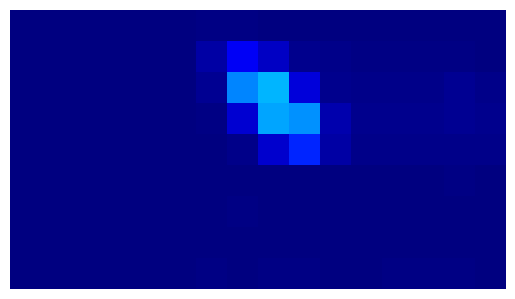

In [31]:
# weak_ver = weak_aug(video1.copy())
# strong_ver = global_aug(video1.copy())
plot_sim_mat(torch.from_numpy(video1), torch.from_numpy(video2), apply_visil=True, save_file=f'{PROJECT_ROOT}/data/examples/sim_mats/self_sim')
# plot_sim_mat(weak_ver, weak_ver, apply_visil=True, save_file=f'{PROJECT_ROOT}/data/examples/sim_mats/self_sim_visil')

In [ ]:
# calculate_video_similarity(weak_ver, weak_ver)

Check dims 1
Check dims 2


#### **Similarity matrix with another weakly augmented version**
Very similar to the previous matrix. Only slightly affects similarity due to minor transformations.

similarity matrix shape: (64, 64)


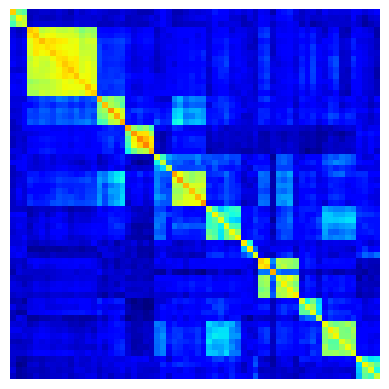

similarity matrix shape: (16, 16)


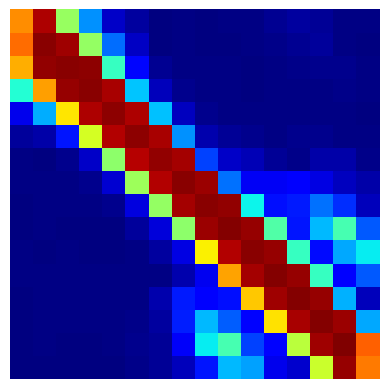

In [ ]:
weak_ver2 = weak_aug(video.copy())
plot_sim_mat(weak_ver, weak_ver2, save_file='data/examples/sim_mats/weak')
plot_sim_mat(weak_ver, weak_ver2, apply_visil=True, save_file='data/examples/sim_mats/weak_visil')

#### **Similarity matrix with an augmented version with Global Transformations**
Noticeable impact on the similarity strength on the block diagonal structures. The global structure is maintained.

similarity matrix shape: (64, 64)


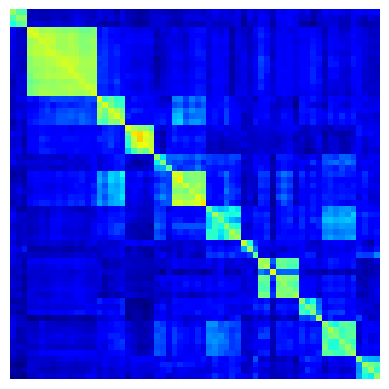

similarity matrix shape: (16, 16)


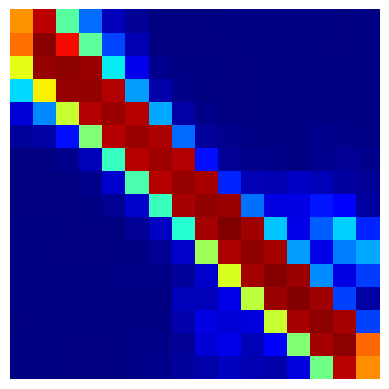

In [ ]:
global_ver = global_aug(video.copy())
plot_sim_mat(weak_ver, global_ver, save_file='data/examples/sim_mats/global')
plot_sim_mat(weak_ver, global_ver, apply_visil=True, save_file='data/examples/sim_mats/global_visil')

#### **Similarity matrix with an augmented version with Frame Transformations**
Noticeable impact on the temporal structures introducing blue vertical lines in the matrix.

similarity matrix shape: (64, 64)


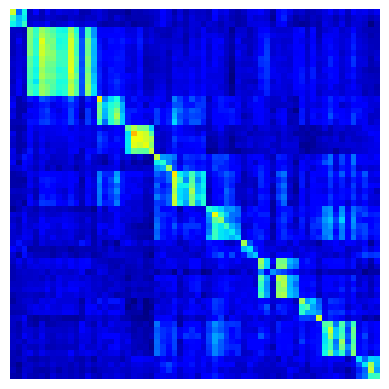

similarity matrix shape: (16, 16)


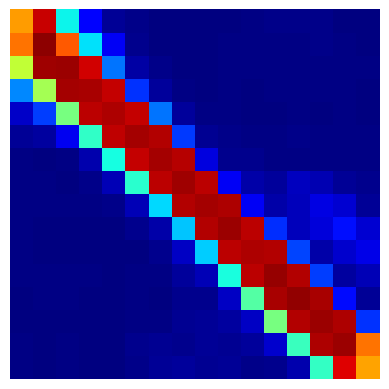

In [ ]:
frame_ver = frame_aug(video.copy())
plot_sim_mat(weak_ver, frame_ver, save_file='data/examples/sim_mats/frame')
plot_sim_mat(weak_ver, frame_ver, apply_visil=True, save_file='data/examples/sim_mats/frame_visil')

#### **Similarity matrix with an augmented version with Temporal Transformations**
Significantly alter the global temporal structure while keeping some local structures.

similarity matrix shape: (64, 64)


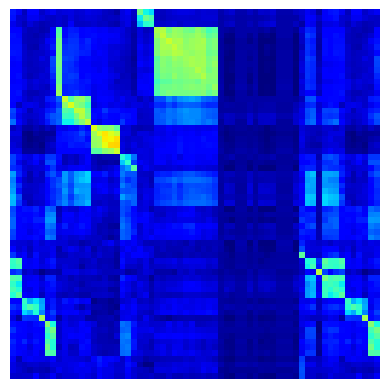

similarity matrix shape: (16, 16)


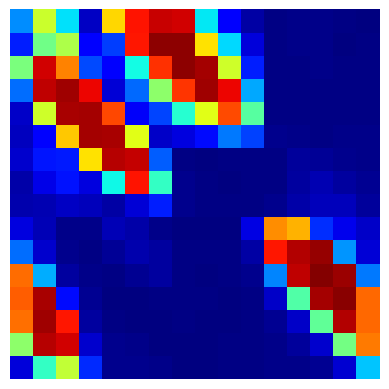

In [ ]:
temp_ver = temporal_aug(video.copy())
plot_sim_mat(weak_ver, temp_ver, save_file='data/examples/sim_mats/temporal')
plot_sim_mat(weak_ver, temp_ver, apply_visil=True, save_file='data/examples/sim_mats/temporal_visil')

#### **Similarity matrix with an augmented version with Video-in-Video Transformation**
Substantial impact on the intensity of the main diagonal.

similarity matrix shape: (64, 64)


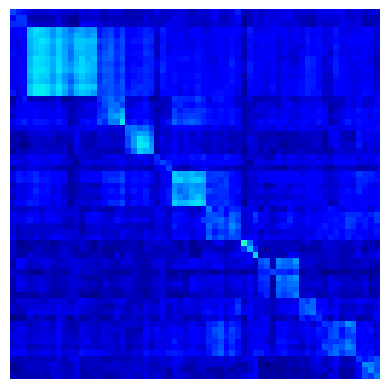

similarity matrix shape: (16, 16)


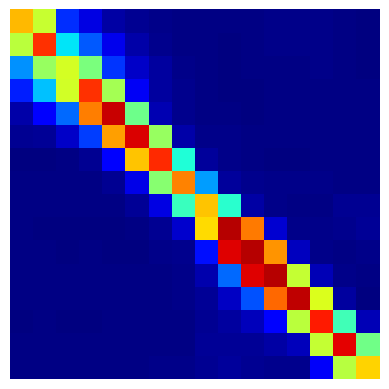

In [ ]:
viv_aug = StrongAugmentations(window_sz=64, augmentations='ViV', p_viv=1.)
video2 = load_video_opencv('data/examples/video1.mp4')[:64]

batch = torch.cat([weak_aug(video.copy())[None, ...], weak_aug(video2.copy())[None, ...]])

viv_ver, _ = viv_aug.mixup(batch, np.array([[1., 0.], [0., 1.]]))
plot_sim_mat(weak_ver, viv_ver[0], save_file='data/examples/sim_mats/viv')
plot_sim_mat(weak_ver, viv_ver[0], apply_visil=True, save_file='data/examples/sim_mats/viv_visil')